In [ ]:
# Exploratory Data Analysis

## E-Commerce Order Analytics

This notebook explores customer behavior, product performance, revenue trends, order statuses, payment methods, coupon usage, and referral-source performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(
    "../data/processed/ecommerce_cleaned.csv"
)

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,ReferralSource,TotalPrice,Year,Month,MonthName,DayOfWeek,DayOfMonth,CustomerOrderCount,CustomerType,UsedCoupon
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,...,Instagram,2853.10,2023,1,January,Wednesday,4,1,One-Time Customer,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,...,Referral,302.70,2024,8,August,Friday,23,1,One-Time Customer,1
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,...,Email,2753.40,2024,2,February,Tuesday,27,1,One-Time Customer,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,...,Facebook,273.19,2023,10,October,Sunday,15,1,One-Time Customer,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,...,Email,2504.04,2025,5,May,Thursday,8,1,One-Time Customer,1


In [3]:
df.shape

(1200, 22)

In [4]:
product_revenue = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

Product
Printer    195585.6750
Chair      195565.6175
Laptop     192044.1750
Tablet     186403.1650
Monitor    175590.8675
Desk       167459.9300
Phone      151722.3900
Name: TotalPrice, dtype: float64

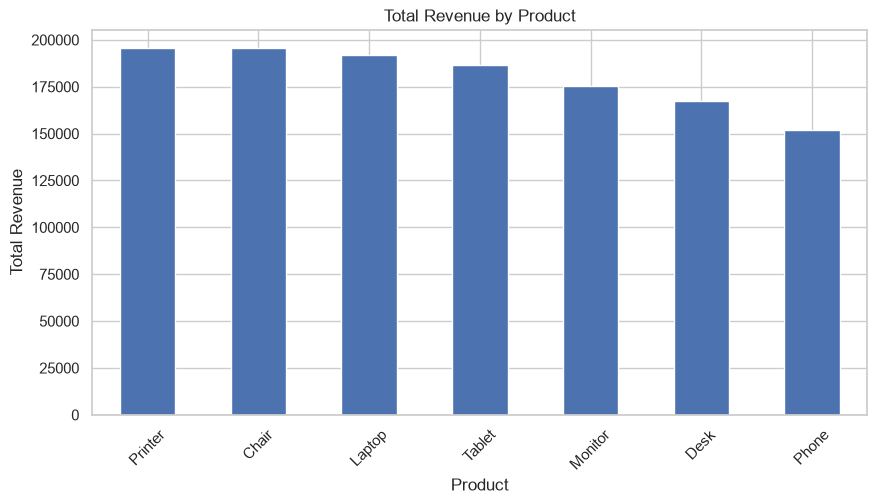

In [5]:
plt.figure(figsize=(10, 5))

product_revenue.plot(kind="bar")

plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.show()

In [6]:
product_orders = (
    df["Product"]
    .value_counts()
)

product_orders

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

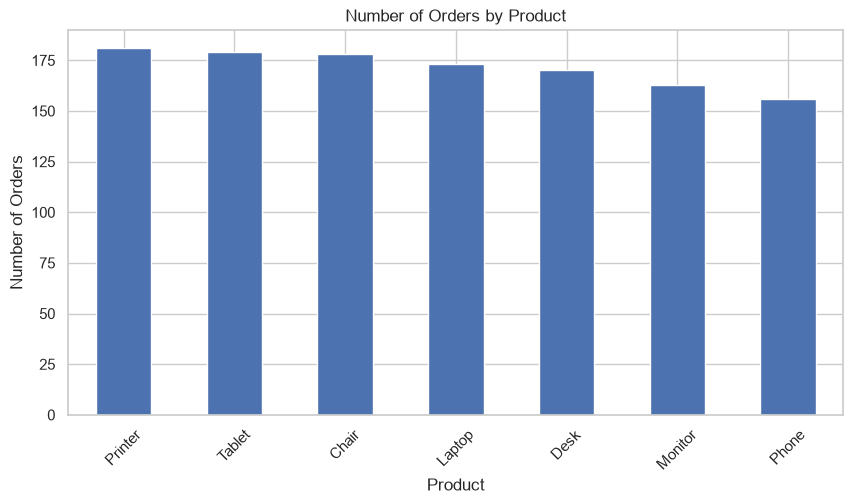

In [7]:
plt.figure(figsize=(10, 5))

product_orders.plot(kind="bar")

plt.title("Number of Orders by Product")
plt.xlabel("Product")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.show()

In [8]:
average_order_value = (
    df.groupby("Product")["TotalPrice"]
    .mean()
    .sort_values(ascending=False)
)

average_order_value

Product
Laptop     1110.081936
Chair      1098.683244
Printer    1080.583840
Monitor    1077.244586
Tablet     1041.358464
Desk        985.058412
Phone       972.579423
Name: TotalPrice, dtype: float64

In [9]:
order_status_counts = (
    df["OrderStatus"]
    .value_counts()
)

order_status_counts

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

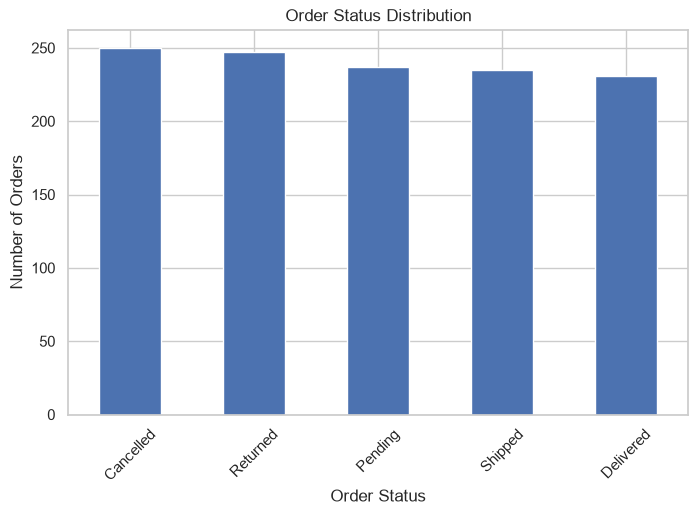

In [10]:
plt.figure(figsize=(8, 5))

order_status_counts.plot(
    kind="bar"
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.show()

In [11]:
cancellation_rate = (
    df["OrderStatus"].eq("Cancelled").mean() * 100
)

print(
    f"Cancellation Rate: {cancellation_rate:.2f}%"
)

Cancellation Rate: 20.83%


In [12]:
return_rate = (
    df["OrderStatus"].eq("Returned").mean() * 100
)

print(
    f"Return Rate: {return_rate:.2f}%"
)

Return Rate: 20.58%


In [13]:
payment_counts = (
    df["PaymentMethod"]
    .value_counts()
)

payment_counts

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

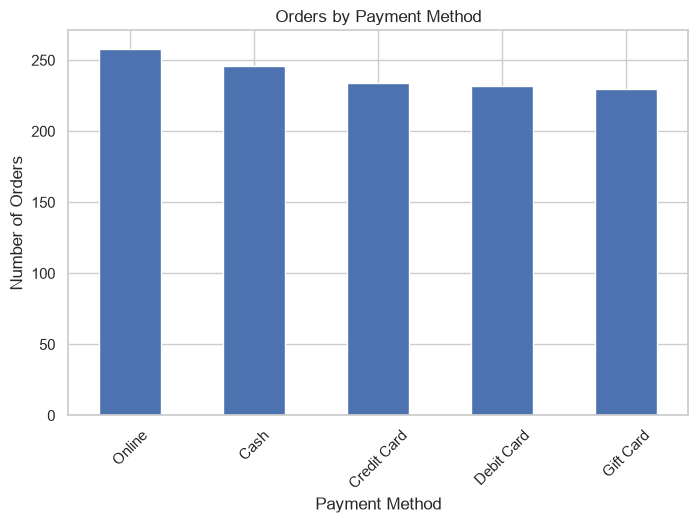

In [14]:
plt.figure(figsize=(8, 5))

payment_counts.plot(
    kind="bar"
)

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.show()

In [15]:
payment_revenue = (
    df.groupby("PaymentMethod")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

PaymentMethod
Credit Card    263847.6300
Online         262216.6125
Cash           259731.7975
Gift Card      246218.1925
Debit Card     232357.5875
Name: TotalPrice, dtype: float64

In [16]:
referral_analysis = (
    df.groupby("ReferralSource")
    .agg(
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="Revenue",
        ascending=False
    )
)

referral_analysis

,Orders,Revenue,AverageOrderValue
ReferralSource,,,
Instagram,259,275262.1075,1062.788060
Email,250,261682.5575,1046.730230
Google,241,250401.6875,1039.011151
Facebook,228,250213.4800,1097.427544
Referral,222,226811.9875,1021.675619


In [17]:
coupon_analysis = (
    df.groupby("CouponCode")
    .agg(
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="Revenue",
        ascending=False
    )
)

coupon_analysis

,Orders,Revenue,AverageOrderValue
CouponCode,,,
FREESHIP,313,335013.6475,1070.331142
NO_COUPON,309,322286.3750,1042.997977
SAVE10,286,304648.6500,1065.205070
WINTER15,292,302423.1475,1035.695711


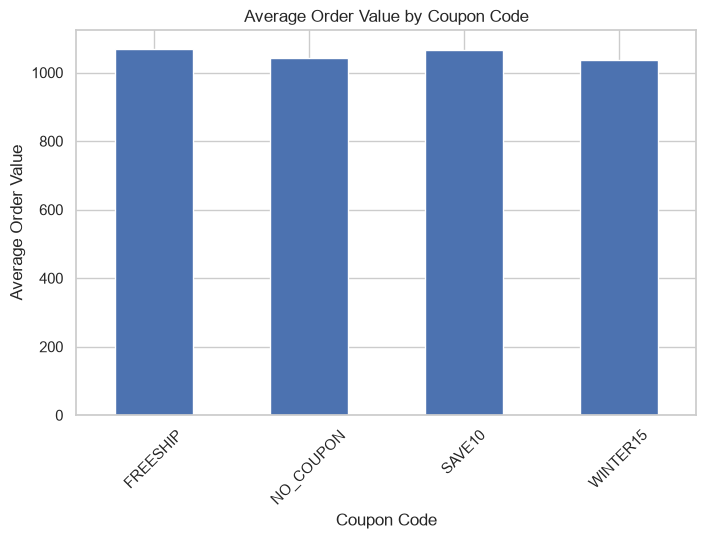

In [18]:
plt.figure(figsize=(8, 5))

coupon_analysis["AverageOrderValue"].plot(
    kind="bar"
)

plt.title("Average Order Value by Coupon Code")
plt.xlabel("Coupon Code")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)
plt.show()

In [19]:
customer_type_analysis = (
    df.groupby("CustomerType")
    .agg(
        Customers=("CustomerID", "nunique"),
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
)

customer_type_analysis

,Customers,Orders,Revenue,AverageOrderValue
CustomerType,,,,
One-Time Customer,1178,1178,1.244897e+06,1056.788270
Repeat Customer,11,22,1.947524e+04,885.238068


In [20]:
monthly_revenue = (
    df.groupby(
        ["Year", "Month"]
    )["TotalPrice"]
    .sum()
)

monthly_revenue

Year  Month
2023  1        56685.7500
      2        40077.8675
      3        48586.0275
      4        27751.7100
      5        63776.4475
      6        49439.6475
      7        42820.6600
      8        54226.1475
      9        29526.6700
      10       52604.2575
      11       43025.1775
      12       43754.7300
2024  1        38528.0800
      2        36909.5700
      3        36030.9000
      4        49613.1400
      5        27909.1100
      6        68068.5400
      7        42941.9875
      8        31991.0700
      9        39794.9800
      10       37226.9700
      11       32413.7600
      12       38785.7700
2025  1        29099.4000
      2        35317.5500
      3        39200.6600
      4        31821.2000
      5        43396.6400
      6        53047.4000
Name: TotalPrice, dtype: float64

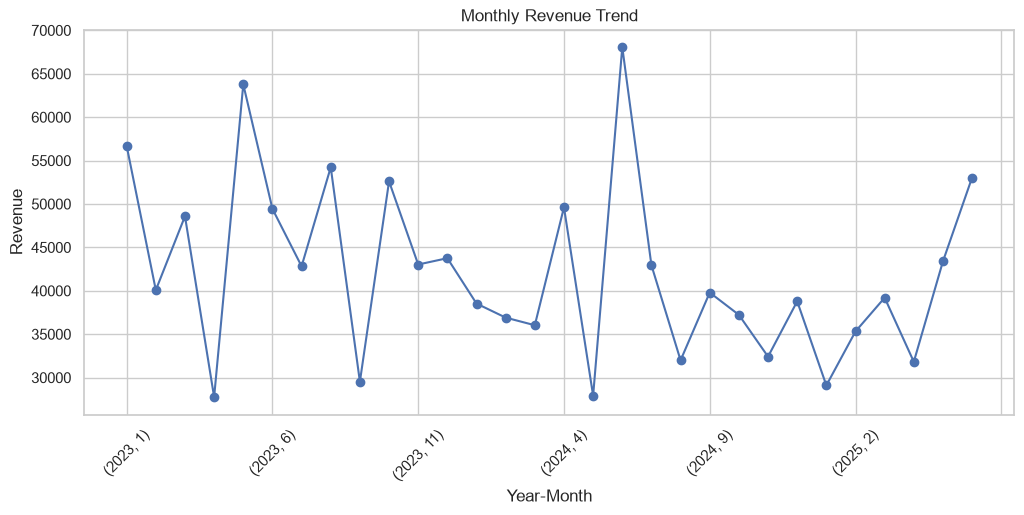

In [21]:
plt.figure(figsize=(12, 5))

monthly_revenue.plot(
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

In [22]:
numeric_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "CustomerOrderCount"
]

In [23]:
correlation_matrix = (
    df[numeric_columns]
    .corr()
)

correlation_matrix

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CustomerOrderCount
Quantity,1.000000,0.014553,0.650061,0.615362,-0.021229
UnitPrice,0.014553,1.000000,0.000602,0.717232,-0.026779
ItemsInCart,0.650061,0.000602,1.000000,0.392579,-0.026334
TotalPrice,0.615362,0.717232,0.392579,1.000000,-0.028114
CustomerOrderCount,-0.021229,-0.026779,-0.026334,-0.028114,1.000000


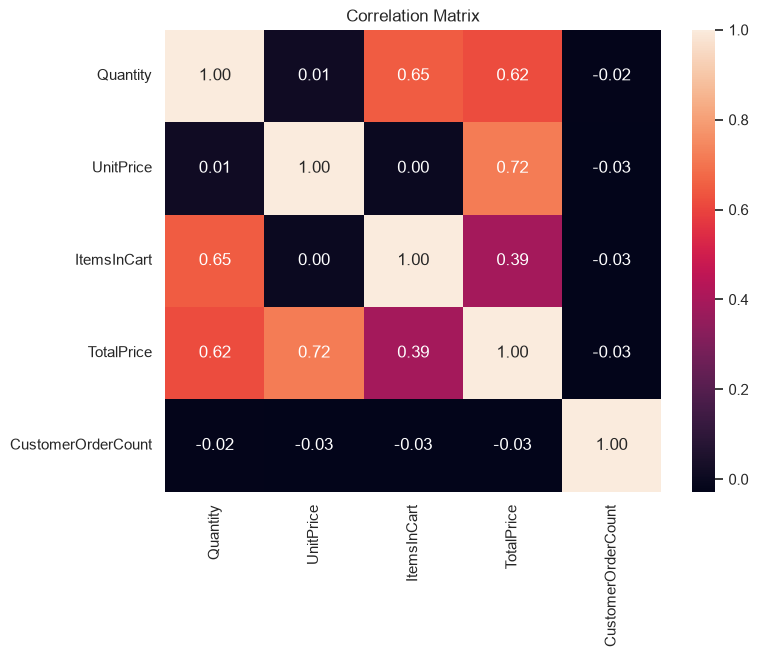

In [24]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
## 2. Order Status Analysis

This section analyzes the distribution of order statuses and evaluates cancellation and return rates to identify potential operational issues.

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")


In [7]:
df = pd.read_csv(
    "../data/processed/ecommerce_cleaned.csv"
)

In [8]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,ReferralSource,TotalPrice,Year,Month,MonthName,DayOfWeek,DayOfMonth,CustomerOrderCount,CustomerType,UsedCoupon
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,...,Instagram,2853.10,2023,1,January,Wednesday,4,1,One-Time Customer,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,...,Referral,302.70,2024,8,August,Friday,23,1,One-Time Customer,1
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,...,Email,2753.40,2024,2,February,Tuesday,27,1,One-Time Customer,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,...,Facebook,273.19,2023,10,October,Sunday,15,1,One-Time Customer,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,...,Email,2504.04,2025,5,May,Thursday,8,1,One-Time Customer,1


In [9]:
df.shape

(1200, 22)

In [10]:
order_status_counts = (
    df["OrderStatus"]
    .value_counts()
)

order_status_counts

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [11]:
order_status_percentage = (
    df["OrderStatus"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

order_status_percentage

OrderStatus
Cancelled    20.83
Returned     20.58
Pending      19.75
Shipped      19.58
Delivered    19.25
Name: proportion, dtype: float64

In [12]:
status_revenue = (
    df.groupby("OrderStatus")
    .agg(
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="Revenue",
        ascending=False
    )
)

status_revenue

,Orders,Revenue,AverageOrderValue
OrderStatus,,,
Cancelled,250,276301.9250,1105.207700
Pending,237,256328.1500,1081.553376
Shipped,235,246136.2375,1047.388245
Returned,247,243195.1650,984.595810
Delivered,231,242410.3425,1049.395422


In [13]:
order_status_counts = (
    df["OrderStatus"]
    .value_counts()
)

order_status_counts

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

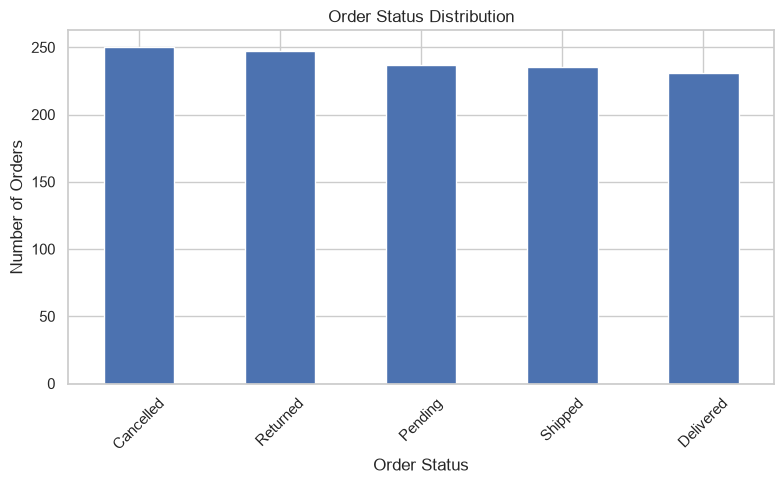

In [14]:
plt.figure(figsize=(8, 5))

order_status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
order_status_percentage = (
    df["OrderStatus"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

order_status_percentage

OrderStatus
Cancelled    20.83
Returned     20.58
Pending      19.75
Shipped      19.58
Delivered    19.25
Name: proportion, dtype: float64

In [16]:
cancellation_rate = (
    df["OrderStatus"].eq("Cancelled").mean() * 100
)

return_rate = (
    df["OrderStatus"].eq("Returned").mean() * 100
)

print(f"Cancellation Rate: {cancellation_rate:.2f}%")
print(f"Return Rate: {return_rate:.2f}%")

Cancellation Rate: 20.83%
Return Rate: 20.58%


In [17]:
status_revenue = (
    df.groupby("OrderStatus")
    .agg(
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="Revenue",
        ascending=False
    )
)

status_revenue

,Orders,Revenue,AverageOrderValue
OrderStatus,,,
Cancelled,250,276301.9250,1105.207700
Pending,237,256328.1500,1081.553376
Shipped,235,246136.2375,1047.388245
Returned,247,243195.1650,984.595810
Delivered,231,242410.3425,1049.395422


In [ ]:
### Key Insights

- Cancelled orders represent 20.83% of all orders.
- Returned orders represent 20.58% of all orders.
- Combined, cancelled and returned orders account for 41.42% of all orders.
- Cancelled orders have the highest average order value at approximately 1,105.21.
- Delivered orders have the lowest total revenue among all order statuses.
- Revenue associated with cancelled or returned orders should not necessarily be considered realized revenue because these transactions may be refunded or reversed.

In [18]:
realized_statuses = [
    "Delivered",
    "Shipped"
]

df["RealizedRevenue"] = np.where(
    df["OrderStatus"].isin(realized_statuses),
    df["TotalPrice"],
    0
)

In [19]:
realized_revenue = df["RealizedRevenue"].sum()

total_recorded_revenue = df["TotalPrice"].sum()

print(
    f"Total Recorded Revenue: {total_recorded_revenue:,.2f}"
)

print(
    f"Estimated Realized Revenue: {realized_revenue:,.2f}"
)

Total Recorded Revenue: 1,264,371.82
Estimated Realized Revenue: 488,546.58


In [20]:
revenue_at_risk = df.loc[
    df["OrderStatus"].isin(
        ["Cancelled", "Returned"]
    ),
    "TotalPrice"
].sum()

print(
    f"Revenue at Risk: {revenue_at_risk:,.2f}"
)

Revenue at Risk: 519,497.09


In [21]:
payment_counts = (
    df["PaymentMethod"]
    .value_counts()
)

payment_counts

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [22]:
payment_analysis = (
    df.groupby("PaymentMethod")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="TotalRevenue",
        ascending=False
    )
)

payment_analysis

,Orders,TotalRevenue,AverageOrderValue
PaymentMethod,,,
Credit Card,234,263847.6300,1127.553974
Online,258,262216.6125,1016.343459
Cash,246,259731.7975,1055.820315
Gift Card,230,246218.1925,1070.513880
Debit Card,232,232357.5875,1001.541325


In [ ]:
## 4. Referral Source Analysis

This section evaluates the performance of different marketing and customer acquisition channels based on order volume, total revenue, and average order value.

In [24]:
referral_analysis = (
    df.groupby("ReferralSource")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="TotalRevenue",
        ascending=False
    )
)

referral_analysis

,Orders,TotalRevenue,AverageOrderValue
ReferralSource,,,
Instagram,259,275262.1075,1062.788060
Email,250,261682.5575,1046.730230
Google,241,250401.6875,1039.011151
Facebook,228,250213.4800,1097.427544
Referral,222,226811.9875,1021.675619


In [25]:
referral_order_percentage = (
    df["ReferralSource"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

referral_order_percentage

ReferralSource
Instagram    21.58
Email        20.83
Google       20.08
Facebook     19.00
Referral     18.50
Name: proportion, dtype: float64

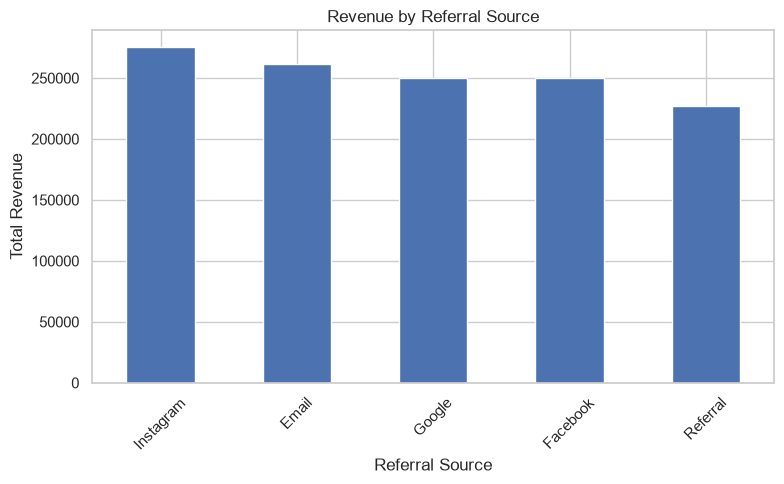

In [26]:
plt.figure(figsize=(8, 5))

referral_analysis["TotalRevenue"].plot(kind="bar")

plt.title("Revenue by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
### Key Insights

- Instagram generated the highest number of orders (259) and the highest total revenue (275,262.11).
- Facebook generated the highest average order value at approximately 1,097.43.
- Email was the second-highest revenue-generating referral source.
- Referral traffic generated the lowest order volume and total revenue.
- Marketing channel performance should be evaluated using both order volume and average order value rather than relying on a single metric.

In [ ]:
## 5. Coupon Performance Analysis

This section analyzes coupon usage and compares revenue and average order value across different coupon codes.

In [27]:
coupon_analysis = (
    df.groupby("CouponCode")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="TotalRevenue",
        ascending=False
    )
)

coupon_analysis

,Orders,TotalRevenue,AverageOrderValue
CouponCode,,,
FREESHIP,313,335013.6475,1070.331142
NO_COUPON,309,322286.3750,1042.997977
SAVE10,286,304648.6500,1065.205070
WINTER15,292,302423.1475,1035.695711


In [28]:
coupon_usage_analysis = (
    df.groupby("UsedCoupon")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
)

coupon_usage_analysis

,Orders,TotalRevenue,AverageOrderValue
UsedCoupon,,,
0,309,322286.375,1042.997977
1,891,942085.445,1057.334955


In [29]:
df["UsedCoupon"] = np.where(
    df["CouponCode"] == "NO_COUPON",
    0,
    1
)

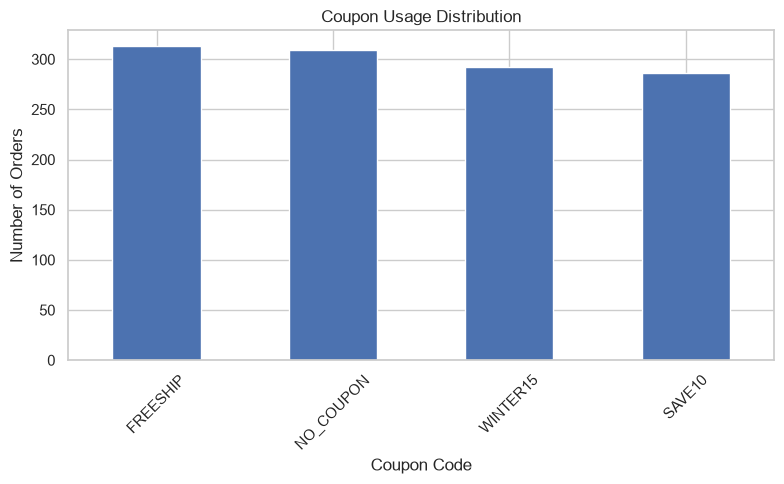

In [30]:
plt.figure(figsize=(8, 5))

df["CouponCode"].value_counts().plot(kind="bar")

plt.title("Coupon Usage Distribution")
plt.xlabel("Coupon Code")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
### Key Insights

- FREESHIP generated the highest order volume (313 orders) and the highest total revenue (335,013.65).
- SAVE10 generated the highest average order value among the percentage-based discount coupons at approximately 1,065.21.
- WINTER15 had the lowest average order value at approximately 1,035.70.
- Orders with FREESHIP had a higher average order value than orders with no coupon.
- Coupon performance should be evaluated using order volume, total revenue, and average order value together.

In [31]:
coupon_usage_analysis = (
    df.groupby("UsedCoupon")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
)

coupon_usage_analysis

,Orders,TotalRevenue,AverageOrderValue
UsedCoupon,,,
0,309,322286.375,1042.997977
1,891,942085.445,1057.334955


In [32]:
df["UsedCoupon"] = np.where(
    df["CouponCode"] == "NO_COUPON",
    0,
    1
)

In [33]:
coupon_usage_analysis = (
    df.groupby("UsedCoupon")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
)

coupon_usage_analysis

,Orders,TotalRevenue,AverageOrderValue
UsedCoupon,,,
0,309,322286.375,1042.997977
1,891,942085.445,1057.334955


In [34]:
coupon_usage_analysis.index = [
    "No Coupon",
    "Used Coupon"
]

coupon_usage_analysis

,Orders,TotalRevenue,AverageOrderValue
No Coupon,309,322286.375,1042.997977
Used Coupon,891,942085.445,1057.334955


In [ ]:
### Coupon Usage Comparison

The `UsedCoupon` feature was created to distinguish between orders where a coupon was used and orders where no coupon was applied.

- `0` represents orders without a coupon.
- `1` represents orders with a coupon.

The comparison evaluates order volume, total revenue, and average order value between coupon users and non-coupon users.

In [ ]:
### Coupon Usage Comparison: Key Insights

- 891 of 1,200 orders used a coupon, representing 74.25% of all orders.
- Coupon-associated orders generated 942,085.45 in recorded revenue.
- The average order value for coupon orders was 1,057.33, compared with 1,043.00 for orders without a coupon.
- Coupon orders had an approximately 1.37% higher average order value in this dataset.
- This analysis shows an association between coupon usage and slightly higher order values; however, it does not prove that coupons directly caused customers to spend more.

In [ ]:
## 6. Customer Behavior Analysis

This section analyzes customer purchasing frequency, identifies repeat customers, and compares the contribution of one-time and repeat customers to overall revenue.

In [35]:
customer_order_counts = (
    df.groupby("CustomerID")["OrderID"]
    .count()
)

customer_order_counts.head()

CustomerID
C10002    1
C10054    1
C10126    1
C10154    1
C10211    1
Name: OrderID, dtype: int64

In [36]:
customer_order_counts.describe()

count    1189.000000
mean        1.009251
std         0.095779
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         2.000000
Name: OrderID, dtype: float64

In [37]:
df["CustomerType"] = np.where(
    df["CustomerOrderCount"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

In [38]:
df["CustomerOrderCount"] = (
    df.groupby("CustomerID")["OrderID"]
    .transform("count")
)

In [39]:
customer_type_analysis = (
    df.groupby("CustomerType")
    .agg(
        UniqueCustomers=("CustomerID", "nunique"),
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
)

customer_type_analysis

,UniqueCustomers,Orders,TotalRevenue,AverageOrderValue
CustomerType,,,,
One-Time Customer,1178,1178,1.244897e+06,1056.788270
Repeat Customer,11,22,1.947524e+04,885.238068


In [ ]:
### Customer Behavior Insights

- The dataset contains 1,189 unique customers.
- 1,178 customers placed only one order, while 11 customers placed multiple orders.
- The repeat-customer rate is approximately 0.93%.
- One-time customers generated the majority of recorded revenue because they represent the overwhelming majority of customers.
- Repeat customers had a lower average order value (885.24) than one-time customers (1,056.79).
- The low repeat-customer rate suggests that customer retention could be an important area for further investigation.
- These findings represent patterns observed within this dataset and should not automatically be generalized to real-world e-commerce behavior.

In [40]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        TotalOrders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
        TotalQuantity=("Quantity", "sum")
    )
    .sort_values(
        by="TotalRevenue",
        ascending=False
    )
)

customer_summary.head(10)

,TotalOrders,TotalRevenue,AverageOrderValue,TotalQuantity
CustomerID,,,,
C38840,2,5662.6875,2831.34375,9
C13877,1,3330.4075,3330.40750,5
C57276,1,3330.4075,3330.40750,5
C47778,1,3330.4075,3330.40750,5
C65986,1,3330.4075,3330.40750,5
C18404,1,3330.4075,3330.40750,5
C67260,1,3330.4075,3330.40750,5
C16775,1,3330.4075,3330.40750,5
C59183,1,3322.5500,3322.55000,5


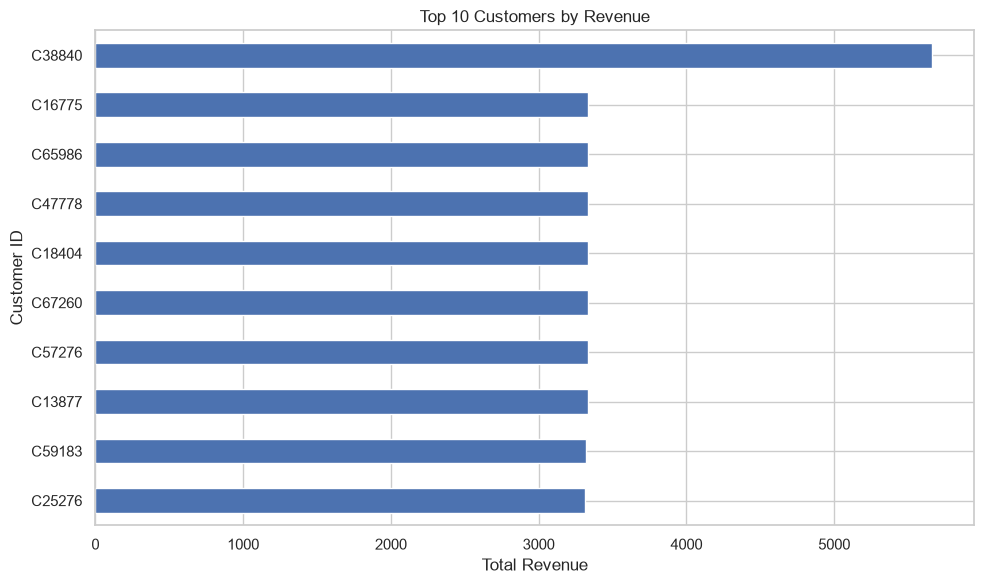

In [41]:
top_10_customers = (
    customer_summary
    .head(10)
    .sort_values(
        by="TotalRevenue"
    )
)

plt.figure(figsize=(10, 6))

top_10_customers["TotalRevenue"].plot(
    kind="barh"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

In [42]:
df["Date"] = pd.to_datetime(df["Date"])

In [43]:
df["YearMonth"] = df["Date"].dt.to_period("M")

In [44]:
df[["Date", "YearMonth"]].head()

,Date,YearMonth
0,2023-01-04,2023-01
1,2024-08-23,2024-08
2,2024-02-27,2024-02
3,2023-10-15,2023-10
4,2025-05-08,2025-05


In [45]:
monthly_analysis = (
    df.groupby("YearMonth")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
        UniqueCustomers=("CustomerID", "nunique")
    )
)

monthly_analysis

,Orders,TotalRevenue,AverageOrderValue,UniqueCustomers
YearMonth,,,,
2023-01,47,56685.7500,1206.079787,47
2023-02,37,40077.8675,1083.185608,37
2023-03,43,48586.0275,1129.907616,43
2023-04,31,27751.7100,895.216452,31
2023-05,49,63776.4475,1301.560153,49
2023-06,45,49439.6475,1098.658833,45
2023-07,44,42820.6600,973.196818,44
2023-08,51,54226.1475,1063.257794,51
2023-09,29,29526.6700,1018.161034,29


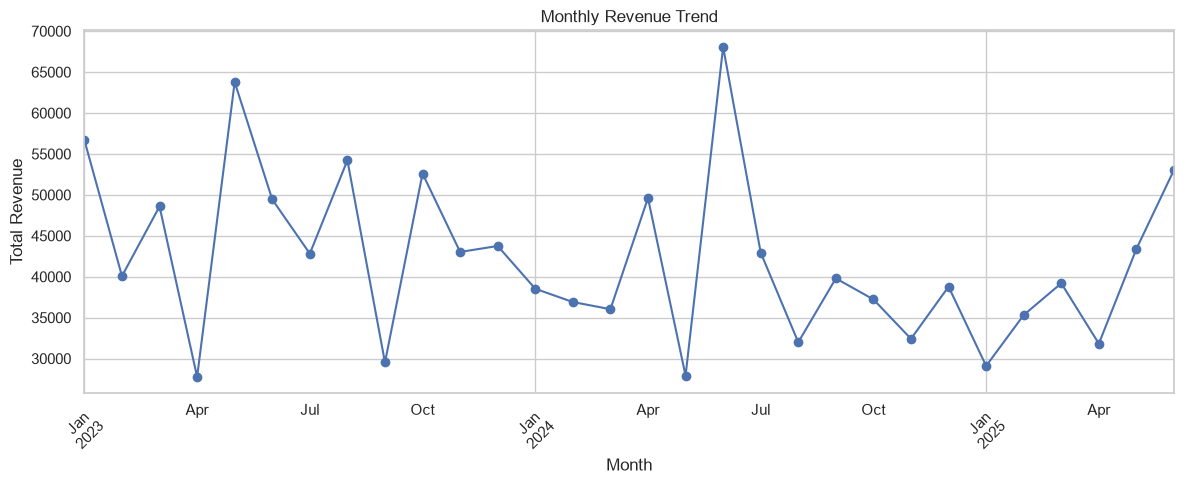

In [46]:
plt.figure(figsize=(12, 5))

monthly_analysis["TotalRevenue"].plot(
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

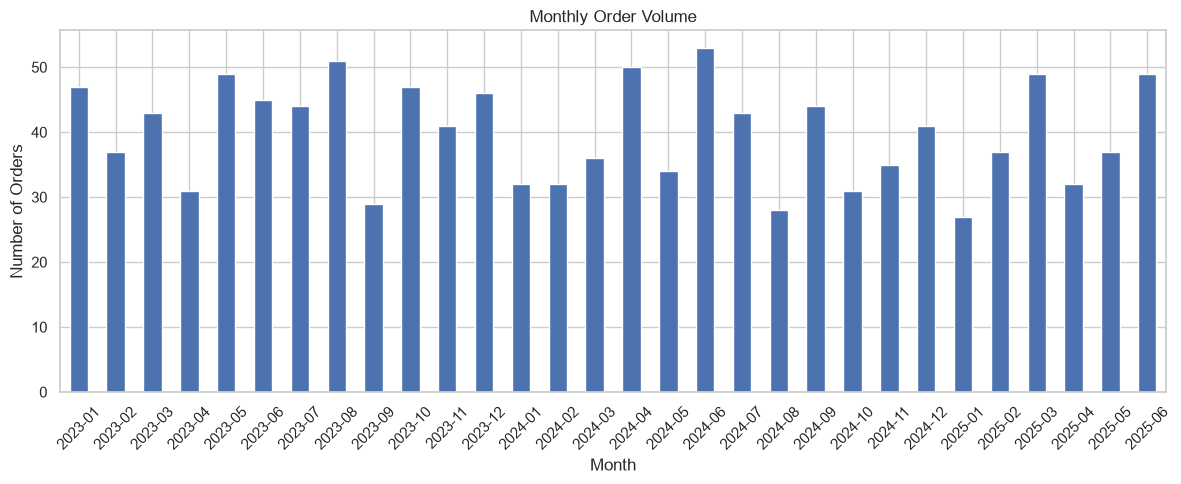

In [47]:
plt.figure(figsize=(12, 5))

monthly_analysis["Orders"].plot(
    kind="bar"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
best_revenue_month = (
    monthly_analysis["TotalRevenue"]
    .idxmax()
)

worst_revenue_month = (
    monthly_analysis["TotalRevenue"]
    .idxmin()
)

print(
    "Best Revenue Month:",
    best_revenue_month
)

print(
    "Worst Revenue Month:",
    worst_revenue_month
)

Best Revenue Month: 2024-06
Worst Revenue Month: 2023-04


In [49]:
print(
    "Highest Revenue:",
    monthly_analysis.loc[
        best_revenue_month,
        "TotalRevenue"
    ]
)

print(
    "Lowest Revenue:",
    monthly_analysis.loc[
        worst_revenue_month,
        "TotalRevenue"
    ]
)

Highest Revenue: 68068.54000000001
Lowest Revenue: 27751.71


In [ ]:
### Monthly Revenue Insights

- The highest-revenue month was [MONTH].
- The lowest-revenue month was [MONTH].
- Monthly revenue showed [stable/fluctuating] performance.
- Changes in revenue were influenced by order volume and average order value.

In [50]:
monthly_analysis

,Orders,TotalRevenue,AverageOrderValue,UniqueCustomers
YearMonth,,,,
2023-01,47,56685.7500,1206.079787,47
2023-02,37,40077.8675,1083.185608,37
2023-03,43,48586.0275,1129.907616,43
2023-04,31,27751.7100,895.216452,31
2023-05,49,63776.4475,1301.560153,49
2023-06,45,49439.6475,1098.658833,45
2023-07,44,42820.6600,973.196818,44
2023-08,51,54226.1475,1063.257794,51
2023-09,29,29526.6700,1018.161034,29


In [ ]:
### Monthly Revenue Insights

- June 2024 generated the highest total revenue at 68,068.54 from 53 orders.
- September 2023 recorded the lowest total revenue at 29,526.67 from 29 orders.
- May 2023 had the highest average order value at 1,301.56.
- June 2024 had the highest order volume with 53 orders.
- Monthly performance fluctuated considerably, with revenue influenced by both order volume and average order value.
- The strongest month was June 2024 because it combined high order volume with a high average order value.

In [ ]:
## 7. Product and Order Status Analysis

This section examines the relationship between product categories and order outcomes to identify products with higher cancellation or return rates.

In [51]:
product_status_counts = pd.crosstab(
    df["Product"],
    df["OrderStatus"]
)

product_status_counts

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
Product,,,,,
Chair,45,33,41,28,31
Desk,35,32,38,32,33
Laptop,35,40,30,39,29
Monitor,35,31,29,36,32
Phone,31,38,28,31,28
Printer,35,29,37,38,42
Tablet,34,28,34,43,40


In [52]:
product_status_percentage = pd.crosstab(
    df["Product"],
    df["OrderStatus"],
    normalize="index"
).mul(100).round(2)

product_status_percentage

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
Product,,,,,
Chair,25.28,18.54,23.03,15.73,17.42
Desk,20.59,18.82,22.35,18.82,19.41
Laptop,20.23,23.12,17.34,22.54,16.76
Monitor,21.47,19.02,17.79,22.09,19.63
Phone,19.87,24.36,17.95,19.87,17.95
Printer,19.34,16.02,20.44,20.99,23.20
Tablet,18.99,15.64,18.99,24.02,22.35


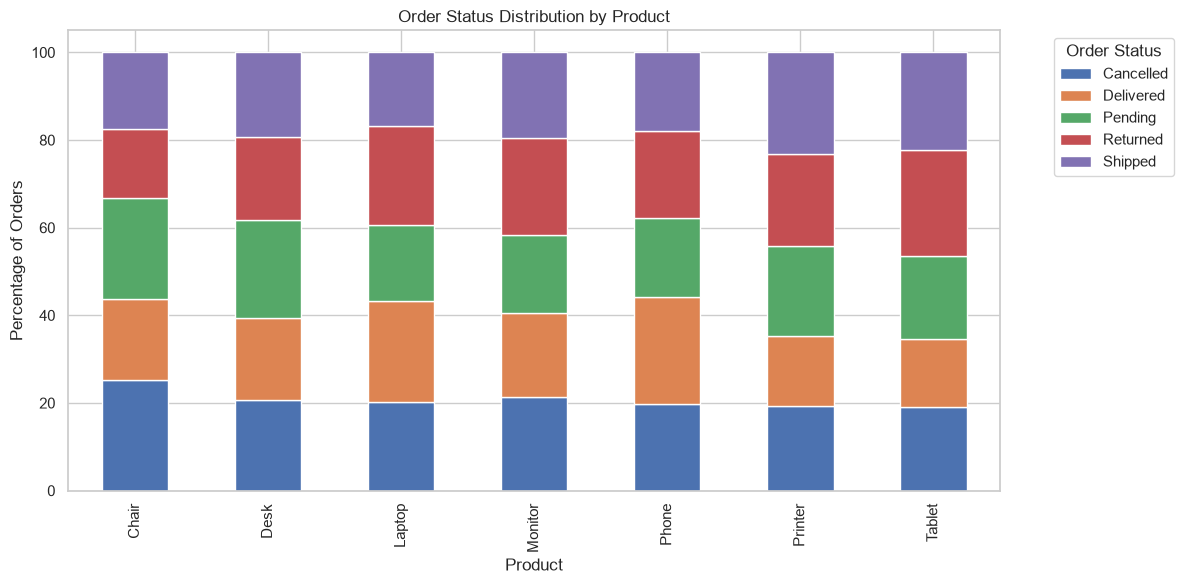

In [53]:
product_status_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Order Status Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Percentage of Orders")

plt.legend(
    title="Order Status",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [54]:
product_risk_analysis = (
    df.assign(
        IsCancelled=df["OrderStatus"].eq("Cancelled"),
        IsReturned=df["OrderStatus"].eq("Returned")
    )
    .groupby("Product")
    .agg(
        TotalOrders=("OrderID", "count"),
        CancelledOrders=("IsCancelled", "sum"),
        ReturnedOrders=("IsReturned", "sum")
    )
)

product_risk_analysis["CancellationRate"] = (
    product_risk_analysis["CancelledOrders"]
    / product_risk_analysis["TotalOrders"]
    * 100
)

product_risk_analysis["ReturnRate"] = (
    product_risk_analysis["ReturnedOrders"]
    / product_risk_analysis["TotalOrders"]
    * 100
)

product_risk_analysis.sort_values(
    by="CancellationRate",
    ascending=False
)

,TotalOrders,CancelledOrders,ReturnedOrders,CancellationRate,ReturnRate
Product,,,,,
Chair,178,45,28,25.280899,15.730337
Monitor,163,35,36,21.472393,22.085890
Desk,170,35,32,20.588235,18.823529
Laptop,173,35,39,20.231214,22.543353
Phone,156,31,31,19.871795,19.871795
Printer,181,35,38,19.337017,20.994475
Tablet,179,34,43,18.994413,24.022346


In [55]:
product_status_counts

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
Product,,,,,
Chair,45,33,41,28,31
Desk,35,32,38,32,33
Laptop,35,40,30,39,29
Monitor,35,31,29,36,32
Phone,31,38,28,31,28
Printer,35,29,37,38,42
Tablet,34,28,34,43,40


In [56]:
product_risk_analysis.sort_values(
    by="CancellationRate",
    ascending=False
)

,TotalOrders,CancelledOrders,ReturnedOrders,CancellationRate,ReturnRate
Product,,,,,
Chair,178,45,28,25.280899,15.730337
Monitor,163,35,36,21.472393,22.085890
Desk,170,35,32,20.588235,18.823529
Laptop,173,35,39,20.231214,22.543353
Phone,156,31,31,19.871795,19.871795
Printer,181,35,38,19.337017,20.994475
Tablet,179,34,43,18.994413,24.022346


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/ecommerce_cleaned.csv")

df["Date"] = pd.to_datetime(df["Date"])
df["YearMonth"] = df["Date"].dt.to_period("M")

df["CustomerOrderCount"] = (
    df.groupby("CustomerID")["OrderID"]
    .transform("count")
)

df["CustomerType"] = np.where(
    df["CustomerOrderCount"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

df["UsedCoupon"] = np.where(
    df["CouponCode"] == "NO_COUPON",
    0,
    1
)

In [2]:
product_status_percentage = pd.crosstab(
    df["Product"],
    df["OrderStatus"],
    normalize="index"
).mul(100).round(2)

product_status_percentage

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
Product,,,,,
Chair,25.28,18.54,23.03,15.73,17.42
Desk,20.59,18.82,22.35,18.82,19.41
Laptop,20.23,23.12,17.34,22.54,16.76
Monitor,21.47,19.02,17.79,22.09,19.63
Phone,19.87,24.36,17.95,19.87,17.95
Printer,19.34,16.02,20.44,20.99,23.20
Tablet,18.99,15.64,18.99,24.02,22.35


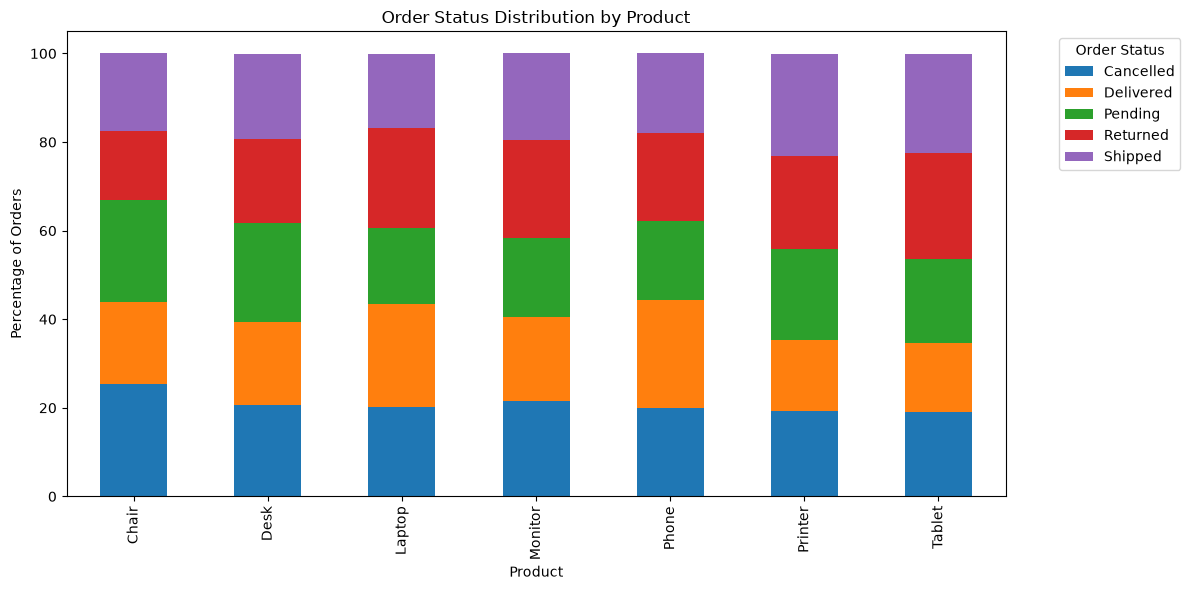

In [3]:
product_status_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Order Status Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Percentage of Orders")

plt.legend(
    title="Order Status",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [4]:
product_risk_analysis = (
    df.assign(
        IsCancelled=df["OrderStatus"].eq("Cancelled"),
        IsReturned=df["OrderStatus"].eq("Returned")
    )
    .groupby("Product")
    .agg(
        TotalOrders=("OrderID","count"),
        CancelledOrders=("IsCancelled","sum"),
        ReturnedOrders=("IsReturned","sum")
    )
)

product_risk_analysis["CancellationRate"] = (
    product_risk_analysis["CancelledOrders"] /
    product_risk_analysis["TotalOrders"] * 100
)

product_risk_analysis["ReturnRate"] = (
    product_risk_analysis["ReturnedOrders"] /
    product_risk_analysis["TotalOrders"] * 100
)

product_risk_analysis.sort_values(
    by="CancellationRate",
    ascending=False
)

,TotalOrders,CancelledOrders,ReturnedOrders,CancellationRate,ReturnRate
Product,,,,,
Chair,178,45,28,25.280899,15.730337
Monitor,163,35,36,21.472393,22.085890
Desk,170,35,32,20.588235,18.823529
Laptop,173,35,39,20.231214,22.543353
Phone,156,31,31,19.871795,19.871795
Printer,181,35,38,19.337017,20.994475
Tablet,179,34,43,18.994413,24.022346


In [5]:
product_performance = (
    df.groupby("Product")
    .agg(
        Orders=("OrderID","count"),
        TotalRevenue=("TotalPrice","sum"),
        AverageOrderValue=("TotalPrice","mean"),
        TotalQuantity=("Quantity","sum")
    )
    .sort_values(
        by="TotalRevenue",
        ascending=False
    )
)

product_performance

,Orders,TotalRevenue,AverageOrderValue,TotalQuantity
Product,,,,
Printer,181,195585.6750,1080.583840,542
Chair,178,195565.6175,1098.683244,562
Laptop,173,192044.1750,1110.081936,535
Tablet,179,186403.1650,1041.358464,497
Monitor,163,175590.8675,1077.244586,480
Desk,170,167459.9300,985.058412,508
Phone,156,151722.3900,972.579423,411


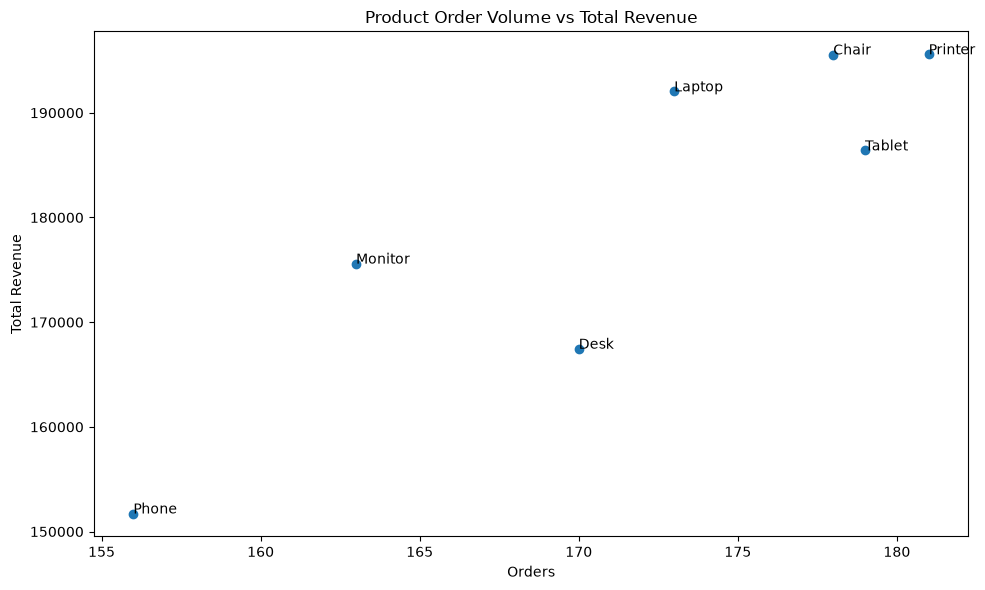

In [6]:
plt.figure(figsize=(10,6))

plt.scatter(
    product_performance["Orders"],
    product_performance["TotalRevenue"]
)

for product, row in product_performance.iterrows():
    plt.annotate(
        product,
        (row["Orders"], row["TotalRevenue"])
    )

plt.title("Product Order Volume vs Total Revenue")
plt.xlabel("Orders")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

In [ ]:
## 9. Customer Acquisition Analysis

This section evaluates the effectiveness of different customer acquisition channels by comparing customer count, order volume, revenue, and average order value.

In [7]:
customer_acquisition = (
    df.groupby("ReferralSource")
    .agg(
        UniqueCustomers=("CustomerID", "nunique"),
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="TotalRevenue",
        ascending=False
    )
)

customer_acquisition

,UniqueCustomers,Orders,TotalRevenue,AverageOrderValue
ReferralSource,,,,
Instagram,257,259,275262.1075,1062.788060
Email,250,250,261682.5575,1046.730230
Google,241,241,250401.6875,1039.011151
Facebook,228,228,250213.4800,1097.427544
Referral,221,222,226811.9875,1021.675619


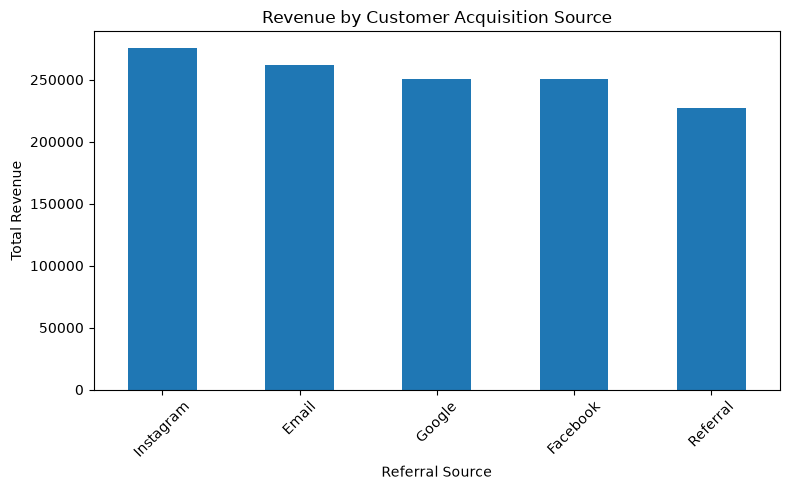

In [8]:
plt.figure(figsize=(8,5))

customer_acquisition["TotalRevenue"].plot(
    kind="bar"
)

plt.title("Revenue by Customer Acquisition Source")
plt.xlabel("Referral Source")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

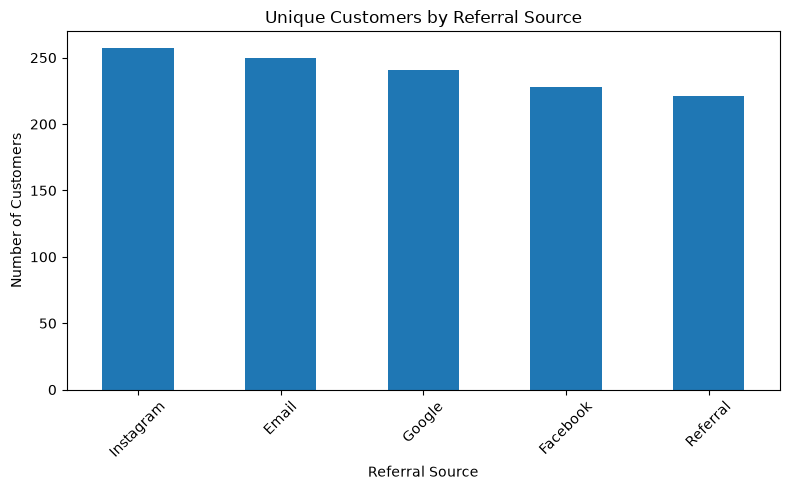

In [10]:
plt.figure(figsize=(8,5))

customer_acquisition["UniqueCustomers"].plot(
    kind="bar"
)

plt.title("Unique Customers by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
### Key Insights

- Instagram acquired the highest number of customers and generated the highest revenue in this dataset.
- Facebook generated the highest average order value despite having fewer customers.
- Email was the second strongest acquisition channel.
- Referral generated the lowest revenue and customer volume.
- Marketing decisions should consider both customer volume and customer value.

In [11]:
payment_status = pd.crosstab(
    df["PaymentMethod"],
    df["OrderStatus"]
)

payment_status

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
PaymentMethod,,,,,
Cash,49,45,52,57,43
Credit Card,54,43,48,49,40
Debit Card,44,43,55,51,39
Gift Card,50,37,35,52,56
Online,53,63,47,38,57


In [12]:
payment_status_percentage = pd.crosstab(
    df["PaymentMethod"],
    df["OrderStatus"],
    normalize="index"
).mul(100).round(2)

payment_status_percentage

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
PaymentMethod,,,,,
Cash,19.92,18.29,21.14,23.17,17.48
Credit Card,23.08,18.38,20.51,20.94,17.09
Debit Card,18.97,18.53,23.71,21.98,16.81
Gift Card,21.74,16.09,15.22,22.61,24.35
Online,20.54,24.42,18.22,14.73,22.09


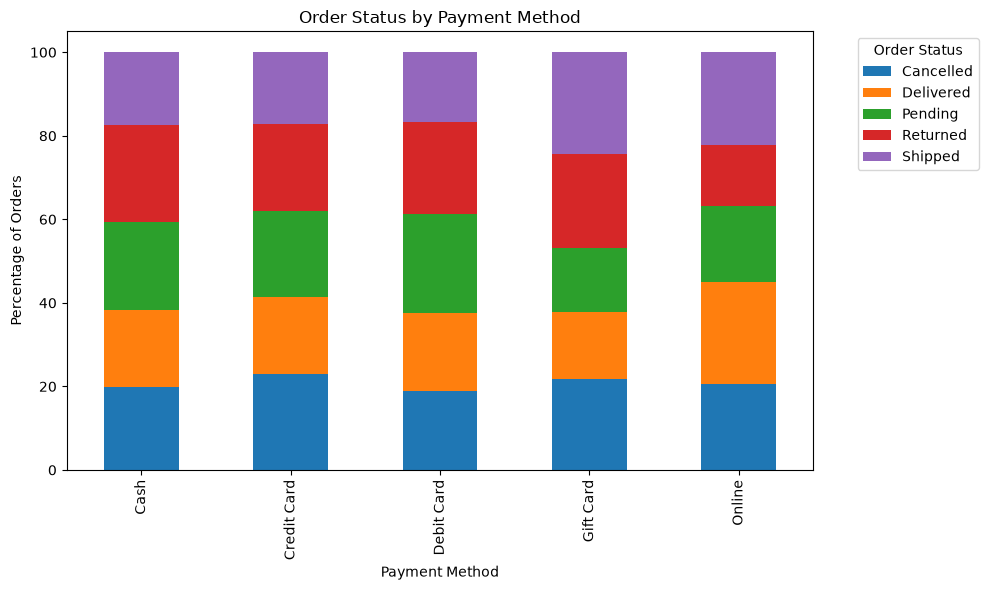

In [13]:
payment_status_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Order Status by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Orders")

plt.legend(
    title="Order Status",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [14]:
numeric_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "CustomerOrderCount"
]

In [15]:
correlation_matrix = (
    df[numeric_columns]
    .corr()
)

correlation_matrix

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CustomerOrderCount
Quantity,1.000000,0.014553,0.650061,0.615362,-0.021229
UnitPrice,0.014553,1.000000,0.000602,0.717232,-0.026779
ItemsInCart,0.650061,0.000602,1.000000,0.392579,-0.026334
TotalPrice,0.615362,0.717232,0.392579,1.000000,-0.028114
CustomerOrderCount,-0.021229,-0.026779,-0.026334,-0.028114,1.000000


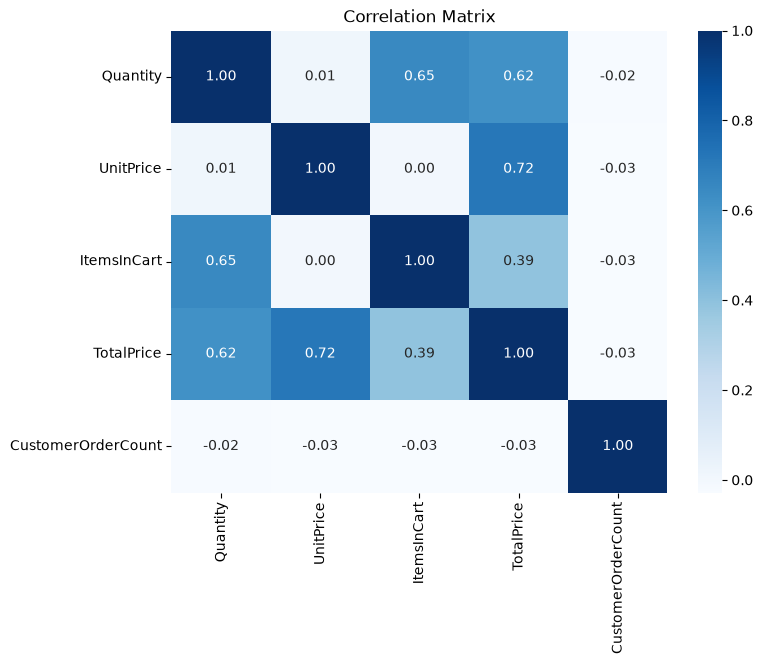

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [17]:
product_performance.to_csv(
    "../reports/product_performance.csv",
    index=True
)

customer_acquisition.to_csv(
    "../reports/customer_acquisition.csv",
    index=True
)

monthly_analysis.to_csv(
    "../reports/monthly_analysis.csv",
    index=True
)

payment_analysis.to_csv(
    "../reports/payment_analysis.csv",
    index=True
)

NameError: name 'monthly_analysis' is not defined

In [18]:
df["Date"] = pd.to_datetime(df["Date"])
df["YearMonth"] = df["Date"].dt.to_period("M")

In [19]:
monthly_analysis = (
    df.groupby("YearMonth")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
        UniqueCustomers=("CustomerID", "nunique")
    )
)

monthly_analysis

,Orders,TotalRevenue,AverageOrderValue,UniqueCustomers
YearMonth,,,,
2023-01,47,56685.7500,1206.079787,47
2023-02,37,40077.8675,1083.185608,37
2023-03,43,48586.0275,1129.907616,43
2023-04,31,27751.7100,895.216452,31
2023-05,49,63776.4475,1301.560153,49
2023-06,45,49439.6475,1098.658833,45
2023-07,44,42820.6600,973.196818,44
2023-08,51,54226.1475,1063.257794,51
2023-09,29,29526.6700,1018.161034,29


In [20]:
product_performance.to_csv(
    "../reports/product_performance.csv",
    index=True
)

customer_acquisition.to_csv(
    "../reports/customer_acquisition.csv",
    index=True
)

monthly_analysis.to_csv(
    "../reports/monthly_analysis.csv",
    index=True
)

payment_analysis.to_csv(
    "../reports/payment_analysis.csv",
    index=True
)

NameError: name 'payment_analysis' is not defined

In [21]:
payment_analysis = (
    df.groupby("PaymentMethod")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="TotalRevenue",
        ascending=False
    )
)

payment_analysis

,Orders,TotalRevenue,AverageOrderValue
PaymentMethod,,,
Credit Card,234,263847.6300,1127.553974
Online,258,262216.6125,1016.343459
Cash,246,259731.7975,1055.820315
Gift Card,230,246218.1925,1070.513880
Debit Card,232,232357.5875,1001.541325


In [22]:
product_performance.to_csv(
    "../reports/product_performance.csv",
    index=True
)

customer_acquisition.to_csv(
    "../reports/customer_acquisition.csv",
    index=True
)

monthly_analysis.to_csv(
    "../reports/monthly_analysis.csv",
    index=True
)

payment_analysis.to_csv(
    "../reports/payment_analysis.csv",
    index=True
)

In [23]:
df["Date"] = pd.to_datetime(df["Date"])
df["YearMonth"] = df["Date"].dt.to_period("M")

monthly_analysis = (
    df.groupby("YearMonth")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean"),
        UniqueCustomers=("CustomerID", "nunique")
    )
)

In [24]:
monthly_analysis.to_csv(
    "../reports/monthly_analysis.csv",
    index=True
)

In [25]:
payment_analysis = (
    df.groupby("PaymentMethod")
    .agg(
        Orders=("OrderID", "count"),
        TotalRevenue=("TotalPrice", "sum"),
        AverageOrderValue=("TotalPrice", "mean")
    )
    .sort_values(
        by="TotalRevenue",
        ascending=False
    )
)

In [26]:
payment_analysis.to_csv(
    "../reports/payment_analysis.csv",
    index=True
)

In [27]:
import os

os.listdir("../reports")

['customer_acquisition.csv',
 'monthly_analysis.csv',
 'payment_analysis.csv',
 'product_performance.csv']

In [28]:
[
 'customer_acquisition.csv',
 'monthly_analysis.csv',
 'payment_analysis.csv',
 'product_performance.csv',
 'figures'
]

['customer_acquisition.csv',
 'monthly_analysis.csv',
 'payment_analysis.csv',
 'product_performance.csv',
 'figures']